<a href="https://colab.research.google.com/github/siddharthvemula/games/blob/master/Homework_02_Multivariate_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Multivariate Regression

**30-minute homework**

**Goal:** Predict startup profit from several inputs while handling one categorical feature.

This is a small, focused version of the workflow used in the [Machine-Learning-Course repository](https://github.com/SuperNova-W/Machine-Learning-Course): inspect → prepare → model → check the result → explain it.

## Timebox and minimum deliverable

- **0–5 min:** inspect the data and run the setup cells
- **5–18 min:** complete the core modeling task
- **18–25 min:** make the required metric or visual check
- **25–30 min:** answer the exit-ticket questions

**Repo reference:** Part2-Regression → Section 5 - Multiple Linear Regression

**Data:** 50_Startups.csv

**Minimum deliverable:** a pipeline with one-hot encoding, test R²/MAE, and the name of the strongest model coefficient.

**Stop here when:** the preprocessing and model run without leakage and you can explain one coefficient cautiously.

Complete the cells marked **TODO**. Keep code readable and add one-sentence interpretations below important outputs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

In [ ]:
df = pd.read_csv("50_Startups.csv")
display(df.head())
X = df.drop(columns=["Profit"])
y = df["Profit"]

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Core task — add features without leaking the answer

Build a pipeline that one-hot encodes `State` and fits `LinearRegression`. Use the same 80/20 split (`random_state=42`) for a fair check.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
prep = ColumnTransformer(
    [("state", OneHotEncoder(handle_unknown="ignore", drop="first"), ["State"])],
    remainder="passthrough",
)
pipeline = Pipeline([("prep", prep), ("model", LinearRegression())])

# TODO: fit the pipeline, predict on the test set, and print R² and MAE
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Test R²: 0.8987266414319837
Test MAE: 6961.477813275567


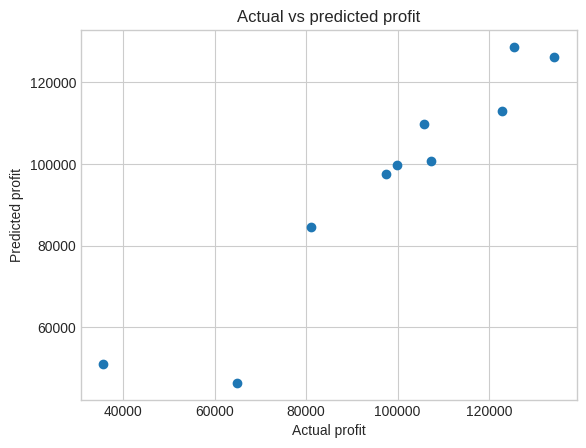

In [ ]:
# TODO: make a compact actual-versus-predicted plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual profit")
plt.ylabel("Predicted profit")
plt.title("Actual vs predicted profit")
plt.show()

In [ ]:
# TODO: inspect coefficients after fitting
names = pipeline.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(pipeline.named_steps["model"].coef_, index=names)
display(coefs.abs().sort_values(ascending=False).head(3))

,0
state__State_Florida,938.793006
state__State_New York,6.987760
remainder__R&D Spend,0.805630


**1.** State_Florida (~939), but features use different scales, so it doesn't mean State matters most.

**2.** The data is observational, so we see patterns, not causes. Other factors like company size could drive both spending and profit.

**3.** The model explains about 90% of the variation in profit on unseen data.

## Exit ticket

Answer briefly in a markdown cell:

1. Which feature has the largest absolute coefficient?
2. Why should a coefficient be treated as an association here, not proof of cause?
3. What does your test R² say in plain language?

## 60-second teach-back

Explain to a partner: **What did the model do? What evidence supports the result? What is one limitation?**

## Optional stretch — only if you finish early

Add a predicted-vs-actual scatter plot and a zero-error reference line.

## Submission check

- [ ] The notebook runs from top to bottom
- [ ] The minimum deliverable is visible
- [ ] The exit ticket is answered
- [ ] The final result includes a plain-language interpretation